## SciPy Spatial Data

Spatial data refers to data that is represented in a geometric space.


E.g. points on a coordinate system.


We deal with spatial data problems on many tasks.


E.g. finding if a point is inside a boundary or not.


SciPy provides us with the module scipy.spatial, which has functions for working with spatial data.



## 1.Triangulation

A Triangulation of a polygon is to divide the polygon into multiple triangles with which we can compute an area of the polygon.

A Triangulation with points means creating surface composed triangles in which all of the given points are on at least one vertex of any triangle in the surface.

One method to generate these triangulations through points is the Delaunay() Triangulation.

In [6]:
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt

points=np.array([
   [2,4],
   [3,4],
   [3,0],
   [2,2],
   [4,1] 
    ])

simplices=Delaunay(points).simplices
simplices

array([[3, 2, 4],
       [3, 1, 0],
       [1, 3, 4]], dtype=int32)

Delaunay triangulation connects the points into triangles such that:

No point lies inside the circumcircle of any triangle. Triangles are as "well-shaped" as possible (avoids skinny triangles).

array([[3, 2, 4],
       [3, 1, 0],
       [1, 3, 4]], dtype=int32)


Each row represents one triangle.


Triangle 1
[3, 2, 4]

Uses points:

3 → (2,2)
2 → (3,0)
4 → (4,1)


Triangle 2
[3, 1, 0]

Uses points:

3 → (2,2)
1 → (3,4)
0 → (2,4)


Triangle 3
[1, 3, 4]

Uses points:

1 → (3,4)
3 → (2,2)
4 → (4,1)

What does simplices mean?

In computational geometry:

0-simplex → point

1-simplex → line segment

2-simplex → triangle

3-simplex → tetrahedron

Since the points are 2D, each simplex is a triangle, represented by the indices of its three vertices.

So:

simplices

simply tells you which points are connected to form each triangle in the Delaunay triangulation

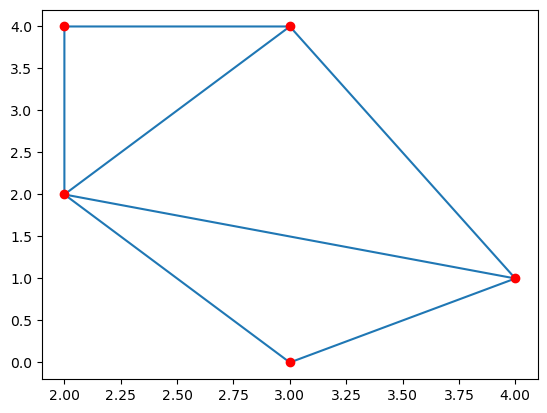

In [10]:
plt.triplot(points[:,0],points[:,1],simplices)
plt.scatter(points[:,0],points[:,1],color='r')

## 2.Convex Hull

A convex hull is the smallest polygon that covers all of the given points.

Use the ConvexHull() method to create a Convex Hull.

In [ ]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

points=np.array([
  [2, 4], ##0
  [3, 4], ##1
  [3, 0], ##2
  [2, 2], ##3
  [4, 1], ##4
  [1, 2], ##5
  [5, 0], ##6
  [3, 1], ##7
  [1, 2], ##8
  [0, 2]  ##9
])
## Notice that point 8 is a duplicate of point 5.
hull=ConvexHull(points)
hull_points=hull.simplices
hull_points

array([[0, 9],
       [1, 6],
       [1, 0],
       [2, 9],
       [2, 6]], dtype=int32)

A convex hull is like stretching a rubber band around all the points.

Only the outermost points touch the rubber band.

For your points, the outer boundary is:

(0,2) → (2,4) → (3,4) → (5,0) → (3,0) → back to (0,2)

The points inside the boundary (such as (2,2), (3,1), (4,1), etc.) are not part of the hull.

Output:

array([
 [0, 9],
 [1, 6],
 [1, 0],
 [2, 9],
 [2, 6]
], dtype=int32)

hull.simplices returns the edges of the convex hull.

Each row contains two indices representing a line segment.


Edge 1:

[0, 9]

Connects:

Point 0 = (2,4)
Point 9 = (0,2)

Edge 2:

[1, 6]

Connects:

Point 1 = (3,4)
Point 6 = (5,0)

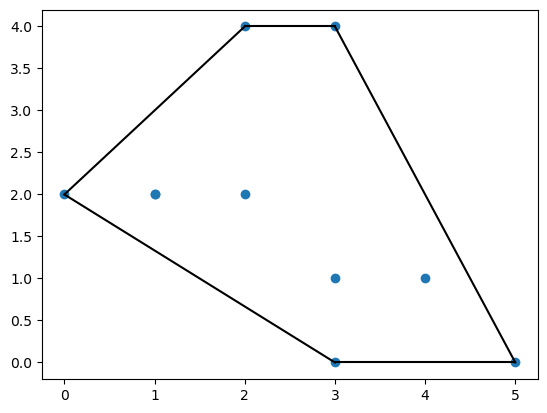

In [13]:
plt.scatter(points[:,0],points[:,1])
for simplex in hull_points:
    plt.plot(points[simplex,0],points[simplex,1],'k-')
plt.show()

## 3.KDTrees

KDTrees are a datastructure optimized for nearest neighbor queries.

E.g. in a set of points using KDTrees we can efficiently ask which points are nearest to a certain given point.

The KDTree() method returns a KDTree object.

The query() method returns the distance to the nearest neighbor and the location of the neighbors.

In [2]:
from scipy.spatial import KDTree
points=[(1,-1),(2,3),(-2,3),(2,-3)]

kdtree=KDTree(points)
kdtree

In [9]:

res = kdtree.query((1, 1))

res


(2.0, np.int64(0))

returns (distance, index)

distance = distance from the query point to the nearest neighbor
index = position of that neighbor in your original points list

(2.0, 0)

This means:

nearest neighbor is at index 0
its coordinates are points[0]

## Distance Matrix

There are many Distance Metrics used to find various types of distances between two points in data science, Euclidean distsane, cosine distsance etc.

The distance between two vectors may not only be the length of straight line between them, it can also be the angle between them from origin, or number of unit steps required etc.

Many of the Machine Learning algorithm's performance depends greatly on distance metrices. E.g. "K Nearest Neighbors", or "K Means" etc.

Let us look at some of the Distance Metrices:



## Eucledian distance


In [10]:
from scipy.spatial.distance import euclidean

p1=(1,0)
p2=(10,2)

res=euclidean(p1,p2)
res

np.float64(9.219544457292887)

## Cityblock distance (Manhattan Distance)

In [11]:
from scipy.spatial.distance import cityblock

p1=(1,0)
p2=(10,2)

res=cityblock(p1,p2)
res

np.int64(11)

## Cosine distance

In [12]:
from scipy.spatial.distance import cosine
p1=(1,0)
p2=(10,2)
res=cosine(p1,p2)
res

np.float64(0.019419324309079777)

## Hamming Distance 

In [ ]:
from scipy.spatial.distance import hamming


p1 = (True, False, True)
p2 = (False, True, True) ## 2 conditions don't match out of 3 so 2/3

res = hamming(p1, p2)

print(res)

0.6666666666666666


In [16]:
from scipy.spatial.distance import hamming


p1 = (1, 0, 1,1,1)
p2 = (0, 1, 1,1,1) ## 2 conditions don't match out of 3 so 2/3

res = hamming(p1, p2)

print(res)

0.4
